## 1. Data Preprocessing
- Handling missing values
- Encoding categorical variables
- Outlier treatment
- Train-test split & Scaling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

# Set plot style
sns.set(style='whitegrid')

# Load Data
df = pd.read_csv('/content/real_estate_investment_dataset.csv')
df.head()

,Total_Square_Footage,Bedrooms,Bathrooms,Age_of_Property,Floor_Number,Furnishing_Status,Neighborhood,Distance_to_City_Center_km,Proximity_to_Public_Transport_km,Crime_Index,Air_Quality_Index,Neighborhood_Growth_Rate_%,Price_per_SqFt,Annual_Property_Tax,Estimated_Rental_Yield_%,Current_Market_Price,Investment_Grade
0,1748.357077,5,3,26,7,Unfurnished,Suburban,16.481757,2.129420,45.0,250.0,4.885652,3839.671746,92506.474881,9.980046,6.713117e+06,0
1,1430.867849,3,4,0,11,Fully-furnished,IT Hub,5.668308,1.415320,82.0,216.0,10.576260,6685.917558,159676.200083,9.828702,9.566664e+06,0
2,1823.844269,3,3,26,2,Semi-furnished,Suburban,13.200650,0.840190,31.0,79.0,8.908252,4759.509657,163275.582676,8.230588,8.680604e+06,1
3,2261.514928,3,4,15,16,Semi-furnished,Suburban,3.672011,0.407293,10.0,226.0,7.691113,4522.943402,167067.631077,2.160537,1.022870e+07,1
4,NaN,5,3,37,20,Unfurnished,Suburban,1.068966,0.225101,78.0,245.0,13.180594,6990.013738,146136.173947,6.347799,9.666653e+06,0


In [ ]:
df.select_dtypes('number').columns

Index(['Total_Square_Footage', 'Bedrooms', 'Bathrooms', 'Age_of_Property',
       'Floor_Number', 'Distance_to_City_Center_km',
       'Proximity_to_Public_Transport_km', 'Crime_Index', 'Air_Quality_Index',
       'Neighborhood_Growth_Rate_%', 'Price_per_SqFt', 'Annual_Property_Tax',
       'Estimated_Rental_Yield_%', 'Current_Market_Price', 'Investment_Grade'],
      dtype='object')

In [ ]:
df.shape

(1800, 17)

In [ ]:
df['Investment_Grade'].value_counts()

,count
Investment_Grade,
0,860
1,836
2,104


In [ ]:
df.select_dtypes('number').columns

Index(['Total_Square_Footage', 'Bedrooms', 'Bathrooms', 'Age_of_Property',
       'Floor_Number', 'Distance_to_City_Center_km',
       'Proximity_to_Public_Transport_km', 'Crime_Index', 'Air_Quality_Index',
       'Neighborhood_Growth_Rate_%', 'Price_per_SqFt', 'Annual_Property_Tax',
       'Estimated_Rental_Yield_%', 'Current_Market_Price', 'Investment_Grade'],
      dtype='object')

In [ ]:
# Numerical Imputation
num_cols = df.select_dtypes('number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical Encoding
furnish_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Fully-furnished': 2}
df['Furnishing_Status'] = df['Furnishing_Status'].map(furnish_map)
df['Furnishing_Status'] = df['Furnishing_Status'].fillna(df['Furnishing_Status'].median())

df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

# Outlier Treatment
for col in num_cols:
    if col not in ['Investment_Grade', 'Current_Market_Price']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)

In [ ]:
df.shape

(1800, 20)

## 2. Regression Model
Predicting the `Current_Market_Price`.

In [ ]:
X_reg = df.drop(columns=['Current_Market_Price', 'Investment_Grade'])
y_reg = df['Current_Market_Price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg_scaled)

print(f'R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}')
print(f'MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.2f}')

R2 Score: 0.8871
MAE: 606361.37


## 3. Classification Model
Predicting the `Investment_Grade`.

In [ ]:
# Advanced: Use predicted price as a feature
X_all_scaled = scaler.transform(X_reg)
df['Predicted_Price'] = reg_model.predict(X_all_scaled)

X_clf = df.drop(columns=['Investment_Grade', 'Current_Market_Price'])
y_clf = df['Investment_Grade']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler_clf = MinMaxScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf_scaled)

print(f'Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}')
print('\nClassification Report:\n', classification_report(y_test_clf, y_pred_clf))

Accuracy: 0.9472

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       167
           1       0.90      1.00      0.95       171
           2       1.00      0.55      0.71        22

    accuracy                           0.95       360
   macro avg       0.97      0.83      0.88       360
weighted avg       0.95      0.95      0.94       360



## 4. Visualizations

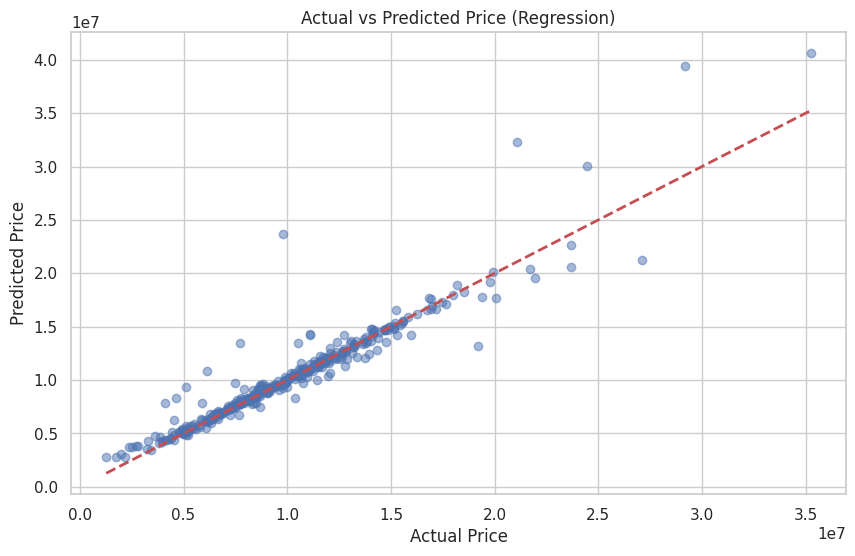

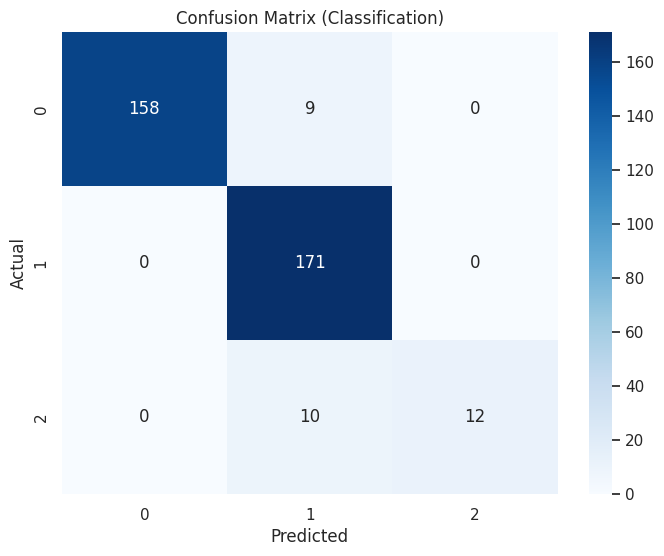

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Regression)')
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Classification)')
plt.show()

## 5. Save Models for Deployment (Streamlit)
Saving models and scalers using `joblib`.

In [ ]:
import joblib

# Save Regression Model and Scaler
joblib.dump(reg_model, 'regression_model.joblib')
joblib.dump(scaler, 'regression_scaler.joblib')

# Save Classification Model and Scaler
joblib.dump(clf_model, 'classification_model.joblib')
joblib.dump(scaler_clf, 'classification_scaler.joblib')

print("Models and scalers saved successfully for deployment!")

Models and scalers saved successfully for deployment!


## 6. Inference on New Data
This block demonstrates how to input string-based categorical data and transform it for prediction.

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Load models and scalers
loaded_reg_model = joblib.load('regression_model.joblib')
loaded_reg_scaler = joblib.load('regression_scaler.joblib')
loaded_clf_model = joblib.load('classification_model.joblib')
loaded_clf_scaler = joblib.load('classification_scaler.joblib')

# Define custom raw features (User inputs as strings/natural numbers)
user_input = {
    'Total_Square_Footage': 1800.0,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Age_of_Property': 5,
    'Floor_Number': 10,
    'Furnishing_Status': 'Semi-furnished', # Actual form: Unfurnished, Semi-furnished, Fully-furnished
    'Neighborhood': 'Industrial',               # Actual form: Downtown, IT Hub, Industrial, Residential, Suburban
    'Distance_to_City_Center_km': 5.0,
    'Proximity_to_Public_Transport_km': 0.5,
    'Crime_Index': 10.0,
    'Air_Quality_Index': 40.0,
    'Neighborhood_Growth_Rate_%': 8.5,
    'Price_per_SqFt': 5500.0,
    'Annual_Property_Tax': 15000.0,
    'Estimated_Rental_Yield_%': 6.0
}

# --- TRANSFORMATION LOGIC ---

# 1. Map Furnishing_Status to Numerical (Ordinal)
furnish_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Fully-furnished': 2}
furnishing_numeric = furnish_map[user_input['Furnishing_Status']] # Default to Semi-furnished if not found

# 2. Handle Neighborhood Encoding (One-Hot Logic with drop_first='Downtown')
# The model expects columns: Neighborhood_IT Hub, Neighborhood_Industrial, Neighborhood_Residential, Neighborhood_Suburban
neighborhoods = ['IT Hub', 'Industrial', 'Residential', 'Suburban']
neighborhood_dummies = {f'Neighborhood_{n}': (1 if user_input['Neighborhood'] == n else 0) for n in neighborhoods}

# 3. Construct Final Feature set in correct order
final_features = {
    'Total_Square_Footage': user_input['Total_Square_Footage'],
    'Bedrooms': user_input['Bedrooms'],
    'Bathrooms': user_input['Bathrooms'],
    'Age_of_Property': user_input['Age_of_Property'],
    'Floor_Number': user_input['Floor_Number'],
    'Furnishing_Status': furnishing_numeric,
    'Distance_to_City_Center_km': user_input['Distance_to_City_Center_km'],
    'Proximity_to_Public_Transport_km': user_input['Proximity_to_Public_Transport_km'],
    'Crime_Index': user_input['Crime_Index'],
    'Air_Quality_Index': user_input['Air_Quality_Index'],
    'Neighborhood_Growth_Rate_%': user_input['Neighborhood_Growth_Rate_%'],
    'Price_per_SqFt': user_input['Price_per_SqFt'],
    'Annual_Property_Tax': user_input['Annual_Property_Tax'],
    'Estimated_Rental_Yield_%': user_input['Estimated_Rental_Yield_%'],
    **neighborhood_dummies
}

# Convert to DataFrame
sample_df = pd.DataFrame([final_features])

# --- PREDICTION ---

# Step 1: Predict Market Price (Regression)
sample_scaled_reg = loaded_reg_scaler.transform(sample_df)
predicted_price = loaded_reg_model.predict(sample_scaled_reg)[0]

# Step 2: Predict Investment Grade (Classification)
# Must add predicted price as a feature for classification
sample_df_clf = sample_df.copy()
sample_df_clf['Predicted_Price'] = predicted_price
sample_scaled_clf = loaded_clf_scaler.transform(sample_df_clf)

predicted_grade = loaded_clf_model.predict(sample_scaled_clf)[0]

print(f"--- Prediction Results ---")
print(f"Input Features: {user_input['Furnishing_Status']} in {user_input['Neighborhood']}")
print(f"Predicted Market Price: {predicted_price:,.2f}")
print(f"Predicted Investment Grade: {predicted_grade}")

--- Prediction Results ---
Input Features: Semi-furnished in Industrial
Predicted Market Price: 9,815,028.11
Predicted Investment Grade: 1


## **Extras : Preprocessing**

In [ ]:
furnish_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Fully-furnished': 2}
user_input['Furnishing_Status']

furnish_map[user_input['Furnishing_Status']]

1

In [ ]:
neighborhoods = ['IT Hub', 'Industrial', 'Residential', 'Suburban']
neighborhood_dummies = {f'Neighborhood_{n}': (1 if user_input['Neighborhood'] == n else 0) for n in neighborhoods}
neighborhood_dummies

{'Neighborhood_IT Hub': 0,
 'Neighborhood_Industrial': 1,
 'Neighborhood_Residential': 0,
 'Neighborhood_Suburban': 0}

In [ ]:
neighborhoods = ['IT Hub', 'Industrial', 'Residential', 'Suburban']

for n in neighborhoods:
  if n == user_input['Neighborhood']:
    print(n , 1)
  else:
    print(n, 0)

IT Hub 0
Industrial 1
Residential 0
Suburban 0
